# Customer Churn Analysis and Prediction

**Author:** Prabin Pokhrel  
**Project:** Customer Churn Prediction & Retention Intelligence  
**Tools:** Python, Scikit-learn, Power BI

---

## Project Overview

This notebook performs exploratory data analysis, feature engineering, and predictive modeling to identify customers at high risk of churn in a telecom dataset. The goal is to support proactive customer retention strategies using data-driven insights.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import warnings
warnings.filterwarnings("ignore")


## Load Dataset

The telecom customer churn dataset is loaded from the raw data folder.

In [4]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

print("Shape:", df.shape)
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Data Understanding

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [6]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

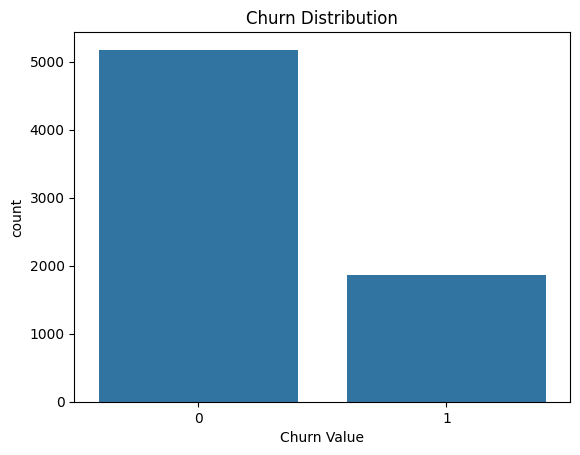

In [7]:
sns.countplot(x='Churn Value', data=df)
plt.title("Churn Distribution")
plt.show()

## Data Cleaning

Key preprocessing steps:

- Convert Total Charges to numeric
- Handle missing values
- Prepare dataset for modeling

In [8]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print("Missing Total Charges:", df['Total Charges'].isnull().sum())

df = df.dropna(subset=['Total Charges'])

print("Shape after drop:", df.shape)

Missing Total Charges: 11
Shape after drop: (7032, 33)


## Feature Engineering

New behavioral features are created to better capture customer risk patterns.

In [9]:
# Tenure groups
df['tenure_group'] = pd.cut(
    df['Tenure Months'],
    bins=[0,12,24,48,72],
    labels=['0-12','13-24','25-48','49-72']
)

# Service count
services = [
    'Online Security','Online Backup','Device Protection',
    'Tech Support','Streaming TV','Streaming Movies'
]

df['service_count'] = (df[services] == 'Yes').sum(axis=1)

# Contract risk
risk_map = {'Month-to-month':3,'One year':2,'Two year':1}
df['contract_risk'] = df['Contract'].map(risk_map)

# Charge ratio
df['charge_ratio'] = df['Monthly Charges'] / (df['Total Charges']/(df['Tenure Months']+1))

## Model Preparation

In [10]:
model_df = df[[
    'Gender','Senior Citizen','Partner','Dependents',
    'Tenure Months','Phone Service','Multiple Lines',
    'Internet Service','Online Security','Online Backup',
    'Device Protection','Tech Support','Streaming TV',
    'Streaming Movies','Contract','Paperless Billing',
    'Payment Method','Monthly Charges','Total Charges',
    'tenure_group','service_count','contract_risk','charge_ratio',
    'Churn Value'
]]

X = model_df.drop('Churn Value', axis=1)
y = model_df['Churn Value']

print("X shape:", X.shape)

X shape: (7032, 23)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

## Logistic Regression Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# -----------------------------
# 1) Train-test split (if not already done)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 2) Identify categorical & numeric columns safely
# -----------------------------
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

# -----------------------------
# 3) Preprocessing: one-hot for categorical, scale numeric
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

# -----------------------------
# 4) Logistic Regression Pipeline
# -----------------------------
log_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=3000))
])

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Results
print("\n Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


📊 Logistic Regression Results
Accuracy: 0.8052594171997157
ROC-AUC: 0.8479184246082486

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.65      0.59      0.62       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.81      0.80      1407



## Random Forest Model

In [15]:
rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7917555081734187
ROC-AUC: 0.8259793136650947
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



## Key Business Insights

- Month-to-month customers exhibit the highest churn risk.
- Customers with fewer add-on services are more likely to churn.
- Higher monthly charges are associated with increased churn probability.
- Contract length is one of the strongest predictors of retention.

These insights support targeted retention strategies such as contract upgrades, service bundling, and pricing optimization.

## Conclusion

This analysis successfully developed a churn prediction framework combining feature engineering, machine learning, and business intelligence. The resulting risk segmentation and dashboard enable proactive customer retention decision-making.

Future improvements may include advanced models, customer lifetime value integration, and real-time scoring pipelines.